# Assignment 5

### <span style="color:chocolate"> Submission requirements </span>

Your work will not be graded if your notebook doesn't include output. In other words, <span style="color:red"> make sure to rerun your notebook before submitting to Gradescope </span> (Note: if you are using Google Colab: go to Edit > Notebook Settings  and uncheck Omit code cell output when saving this notebook, otherwise the output is not printed).

Additional points may be deducted if these requirements are not met:
    
* Comment your code;
* Each graph should have a title, labels for each axis, and (if needed) a legend. Each graph should be understandable on its own;
* Try and minimize the use of the global namespace (meaning, keep things inside functions).

Additional notes:

* Please note that in this assignment, students are expected to work independently. As a result, no two solutions should look identical in terms of coding;
* You may import any libraries you need to complete the assignment. However, you must implement the model using TensorFlow (do not use PyTorch);
* Follow the same steps/idea as in Assignment 4; the difference here is that you extend a logistic model to more than two classes;
* <span style="color:chocolate"> Focus on the execution of the task rather than model performance </span> (this is how the TA will grade your work);
* Even though the prediction performance for your chosen outcome is low, it doesn't necessarily mean there is something wrong with your implementation. It could also be that the data is not supportive enough for your prediction task... again, focus on the learning opportunity and not the numbers you get;
* Your instructional team has extensive experience developing and running ML models. Often, we encounter situations where a model doesn't perform well on a predictive task. This can happen due to the nature of the data or the need for significant tweaking of variables to achieve good results;
* Do not spend significantly more time on this task than you did on Assignment 4, unless you wish to experiment and learn more.
---

``Objective``
* Perform multiclass classification using logistic regression. <span style="color:chocolate"> You will choose the outcome of interest. </span>

``Motivation``
* Chocolate is one of the most popular candies in the world. Each year, residents of the United States collectively eat more than 2.8 billions pounds (Source: Kaggle). However, not all chocolate bars are created equal! In this assignment, you will have the opportunity to delve into the world of chocolate by choosing your own machine learning task. 


``Data``

* The [Chocolate Bar dataset](https://www.kaggle.com/datasets/rtatman/chocolate-bar-ratings) contains expert ratings of 1,795 individual chocolate bars, along with information on their regional origin, percentage of cocoa, the variety of chocolate bean used and where the beans were grown (Source: Kaggle).

### Import libraries

In [1]:
%reset -f
from __future__ import print_function

import math
import numpy as np
import numpy.linalg as nla
import pandas as pd
import re
import six
from os.path import join
import tensorflow as tf
from matplotlib import pyplot as plt
from sklearn.model_selection import train_test_split
from keras_tuner import HyperParameters

# feel free to import other libraries as needed

import warnings
warnings.filterwarnings('ignore')

### Define functions

In [2]:
def read_data():
    ''''''
    # Read data
    df = pd.read_csv(
        "https://download.mlcc.google.com/mledu-datasets/flavors_of_cacao.csv",
        sep=",",
        encoding='latin-1'
    )
    
    return df

In [3]:
def clean_data(df):
    ''''''
    # Set the output display to have one digit for decimal places and limit it to
    # printing 15 rows.
    pd.options.display.float_format = '{:.2f}'.format
    pd.options.display.max_rows = 15
    
    # Rename the columns.
    df.columns = [
        'maker', 'specific_origin', 'reference_number',
        'review_date', 'cocoa_percent', 'maker_location',
        'rating', 'bean_type', 'broad_origin'
    ]

    # df.dtypes

    # Replace empty/null values with "Blend"
    df['bean_type'] = df['bean_type'].fillna('Blend')

    # Cast bean_type to string to remove leading 'u'
    df['bean_type'] = df['bean_type'].astype(str)
    df['cocoa_percent'] = df['cocoa_percent'].str.strip('%')
    df['cocoa_percent'] = pd.to_numeric(df['cocoa_percent'])

    # Correct spelling mistakes, and replace city with country name
    df['maker_location'] = df['maker_location']\
    .str.replace('Amsterdam', 'Holland')\
    .str.replace('U.K.', 'England')\
    .str.replace('Niacragua', 'Nicaragua')\
    .str.replace('Domincan Republic', 'Dominican Republic')

    # Adding this so that Holland and Netherlands map to the same country.
    df['maker_location'] = df['maker_location']\
    .str.replace('Holland', 'Netherlands')

    def cleanup_spelling_abbrev(text):
        replacements = [
            ['-', ', '], ['/ ', ', '], ['/', ', '], ['\(', ', '], [' and', ', '], [' &', ', '], ['\)', ''],
            ['Dom Rep|DR|Domin Rep|Dominican Rep,|Domincan Republic', 'Dominican Republic'],
            ['Mad,|Mad$', 'Madagascar, '],
            ['PNG', 'Papua New Guinea, '],
            ['Guat,|Guat$', 'Guatemala, '],
            ['Ven,|Ven$|Venez,|Venez$', 'Venezuela, '],
            ['Ecu,|Ecu$|Ecuad,|Ecuad$', 'Ecuador, '],
            ['Nic,|Nic$', 'Nicaragua, '],
            ['Cost Rica', 'Costa Rica'],
            ['Mex,|Mex$', 'Mexico, '],
            ['Jam,|Jam$', 'Jamaica, '],
            ['Haw,|Haw$', 'Hawaii, '],
            ['Gre,|Gre$', 'Grenada, '],
            ['Tri,|Tri$', 'Trinidad, '],
            ['C Am', 'Central America'],
            ['S America', 'South America'],
            [', $', ''], [',  ', ', '], [', ,', ', '], ['\xa0', ' '],[',\s+', ','],
            [' Bali', ',Bali']
        ]
        for i, j in replacements:
            text = re.sub(i, j, text)
        return text

    df['specific_origin'] = df['specific_origin'].str.replace('.', '').apply(cleanup_spelling_abbrev)

    # Cast specific_origin to string
    df['specific_origin'] = df['specific_origin'].astype(str)

    # Replace null-valued fields with the same value as for specific_origin
    df['broad_origin'] = df['broad_origin'].fillna(df['specific_origin'])

    # Clean up spelling mistakes and deal with abbreviations
    df['broad_origin'] = df['broad_origin'].str.replace('.', '').apply(cleanup_spelling_abbrev)

    # Change 'Trinitario, Criollo' to "Criollo, Trinitario"
    # Check with df['bean_type'].unique()
    df.loc[df['bean_type'].isin(['Trinitario, Criollo']),'bean_type'] = "Criollo, Trinitario"
    # Confirm with df[df['bean_type'].isin(['Trinitario, Criollo'])]

    # Fix chocolate maker names
    df.loc[df['maker']=='Shattel','maker'] = 'Shattell'
    df['maker'] = df['maker'].str.replace(u'Na\xef\xbf\xbdve','Naive')

    return df

---
### Step 1: Data ingestion

First, we'll initiate the process of discovering the chocolate world by loading the data. Then, to assist with this assignment, we'll start by tidying up the data a little bit. This involves renaming columns and conducting some string preprocessing tasks, which will be handled by the <span style="color:chocolate">clean_data()</span> function mentioned earlier.

In [4]:
df = clean_data(read_data())
print('Shape of data', df.shape)
df.head()

Shape of data (1795, 9)


,maker,specific_origin,reference_number,review_date,cocoa_percent,maker_location,rating,bean_type,broad_origin
0,A. Morin,Agua Grande,1876,2016,63.00,France,3.75,Blend,Sao Tome
1,A. Morin,Kpime,1676,2015,70.00,France,2.75,Blend,Togo
2,A. Morin,Atsane,1676,2015,70.00,France,3.00,Blend,Togo
3,A. Morin,Akata,1680,2015,70.00,France,3.50,Blend,Togo
4,A. Morin,Quilla,1704,2015,70.00,France,3.50,Blend,Peru


### <span style="color:chocolate">Exercise 1:</span> Getting to know the data (5 points)

Answer the following questions:
    
1. How many columns does the dataset contain?
2. How many rows are there in the dataset?
3. What are the column names?
4. List the number of unique values for each column in the data;
5. What are the unique cocoa_percent values?

In [5]:
print("Number of column:", df.shape[1], "\nNumber of rows:", df.shape[0])
print("Column names:", df.columns.to_list())
print("Number of Unique values for each column:\n", df.nunique())
print("Unique cocoa_percent values:", df['cocoa_percent'].nunique())

Number of column: 9 
Number of rows: 1795
Column names: ['maker', 'specific_origin', 'reference_number', 'review_date', 'cocoa_percent', 'maker_location', 'rating', 'bean_type', 'broad_origin']
Number of Unique values for each column:
 maker                414
specific_origin     1038
reference_number     440
review_date           12
cocoa_percent         45
maker_location        58
rating                13
bean_type             39
broad_origin         160
dtype: int64
Unique cocoa_percent values: 45


### <span style="color:chocolate">Exercise 2:</span> Choosing the prediction task (5 points)

Now that you’ve explored the data, choose a multiclass outcome (anything except "ratings") that you’re interested in predicting. Note: The outcome should have <span style="color:chocolate">at least 3 classes</span>!

If your chosen outcome variable requires preprocessing, go ahead and handle that below. For instance, you might choose to predict "cocoa_percent". Discretizing it into "0=low," "1=medium," and "2=high" makes it easier to work with/interpret the results.

Your answer here: 

In [ ]:
#pick cocoa percent with numeric content. Low (<= 80%), Medium (70-80%), high (>80%)
print(df['cocoa_percent'].describe())

df['cocoa_percent_bucket'] = pd.cut(
    df['cocoa_percent'],
    bins=[0,70,80,100],
    labels=['low', 'medium', 'high']
)

print(df['cocoa_percent_bucket'].value_counts())

count   1795.00
mean      71.70
std        6.32
min       42.00
25%       70.00
50%       70.00
75%       75.00
max      100.00
Name: cocoa_percent, dtype: float64
cocoa_percent_bucket
low       1000
medium     684
high       111
Name: count, dtype: int64


---
### Step 2: Data preprocessing

### <span style="color:chocolate">Exercise 3:</span> Prepare data for modeling (20 points)

Following the format of previous assignments, adhere to the following steps as a minimum:

1. Shuffle the dataset;
2. Create training, validation, and test datasets using a 60/20/20 split;
3. Identify the features of interest;
4. Perform necessary cleaning and standarization on the features.

In [11]:

# Feature of interests are rating and review_date 
feature_cols = ['rating', 'review_date']
target_col = 'cocoa_percent_bucket'
# remove N/A
#print(shuffled_df[feature_cols+[target_col]].isnull().sum())
#1. shuffle the dataset
shuffled_df = df.reindex(np.random.RandomState(0).permutation(df.index))
shuffled_df = shuffled_df.dropna(subset=feature_cols + [target_col])

#2. split data to 60/20/20
train_df, temp_df = train_test_split(shuffled_df, test_size=0.4, random_state=0)
val_df, test_df = train_test_split(temp_df, test_size=0.5, random_state=0)

X_train = train_df[feature_cols].values
X_val = val_df[feature_cols].values
X_test = test_df[feature_cols].values

Y_train = train_df[target_col]
Y_val = val_df[target_col]
Y_test = test_df[target_col]

# clean and standarization
label_map = {'low': 0, 'medium': 1, 'high':2}
Y_train = Y_train.map(label_map).values
Y_val = Y_val.map(label_map).values
Y_test = Y_test.map(label_map).values

X_train_mean = X_train.mean(axis = 0)
X_train_std = X_train.std(axis = 0)

X_train = (X_train - X_train_mean)/X_train_std
X_val = (X_val - X_train_mean)/X_train_std
X_test = (X_test - X_train_mean)/X_train_std



---
### Step 3: Exploratory data analysis (EDA)

### <span style="color:chocolate">Exercise 4:</span> Plots (20 points)

In line with the structure of previous assignments, execute the following steps:

1. Generate a minimum of 4 plots to investigate features and outcome within the training dataset;
2. Ensure that each plot includes clear axis labels and titles;
3. Provide commentary on the insights learned from your visualizations.

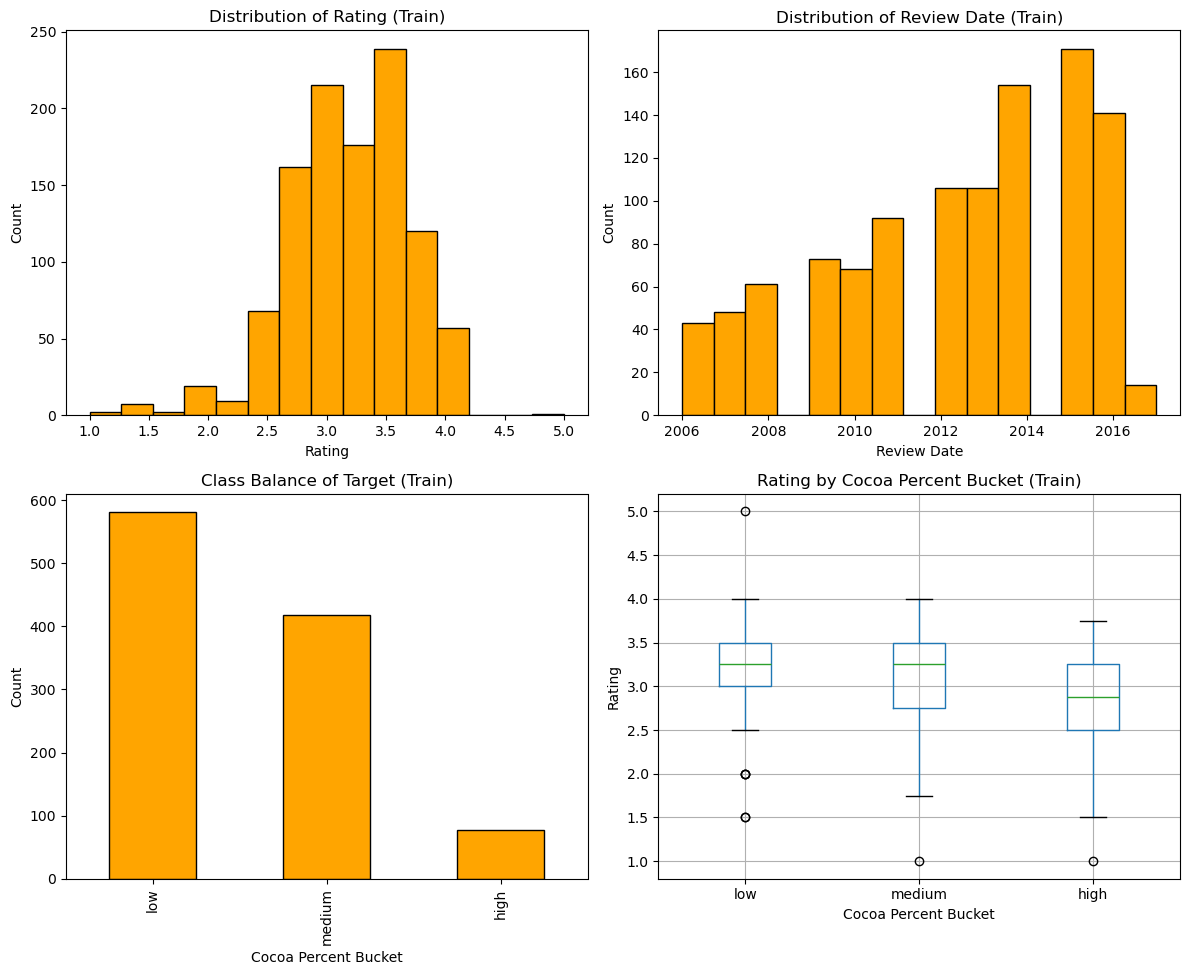

In [18]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

#Distribution of rating in the training set
axes[0,0].hist(train_df['rating'], bins=15, color='orange', edgecolor='black')
axes[0,0].set_xlabel('Rating')
axes[0,0].set_ylabel('Count')
axes[0,0].set_title('Distribution of Rating (Train)')

# Distribution of review_date in the training set
axes[0,1].hist(train_df['review_date'], bins=15, color='orange', edgecolor='black')
axes[0,1].set_xlabel('Review Date')
axes[0,1].set_ylabel('Count')
axes[0,1].set_title('Distribution of Review Date (Train)')

# Class balance of the target
train_df['cocoa_percent_bucket'].value_counts().reindex(['low', 'medium', 'high']).plot(
    kind='bar', ax=axes[1,0], color='orange', edgecolor='black')
axes[1,0].set_xlabel('Cocoa Percent Bucket')
axes[1,0].set_ylabel('Count')
axes[1,0].set_title('Class Balance of Target (Train)')

# Rating by class
train_df.boxplot(column='rating', by='cocoa_percent_bucket', ax=axes[1,1])
axes[1,1].set_xlabel('Cocoa Percent Bucket')
axes[1,1].set_ylabel('Rating')
axes[1,1].set_title('Rating by Cocoa Percent Bucket (Train)')

plt.suptitle('')
plt.tight_layout()
plt.show()

---
### Step 4: Modeling

### <span style="color:chocolate">Exercise 5:</span> Baseline model (10 points)

When dealing with classification problems, a simple baseline is to select the *majority* class (the most common label in the training set) and use it as the prediction for all inputs.

1. Implement this baseline and report the accuracy metric on the train data;

2. Implement a function that computes the Log Loss (cross-entropy loss) metric and use it to evaluate this baseline on both the train and validation data. Note: reflect on what you know about the original distribution of classes in your training data (Hint: see Assignment 4 - Exercise 8 and ``Module Demos/05 Multiclass Logistic Regression.ipynb`` in bCourses for an example).

In [23]:
#find majority
majority_class = np.bincount(Y_train).argmax()
print("Majority Class:", majority_class)

baseline_preds_train = np.full_like(Y_train, fill_value=majority_class)

baseline_train_accuracy = np.mean(baseline_preds_train == Y_train)
print("Baseline train accuracy:", baseline_train_accuracy)

#compute the Log Loss
def log_loss_multiclass(y_true, p):
    #y_true: integer label
    #p: predicted probabilities
    p = np.clip(p, 1e-15, 1-1e-15)
    n = len(y_true)
    true_class_probs = p[np.arange(n), y_true]
    log_loss = -np.mean(np.log(true_class_probs))
    return log_loss

class_counts = np.bincount(Y_train, minlength=3)
baseline_probs = class_counts / class_counts.sum()
print("Baseline probabilities:", baseline_probs)

# broadcast the same probabilities to every row
p_train = np.tile(baseline_probs, (len(Y_train),1))
p_test = np.tile(baseline_probs, (len(Y_test), 1))

baseline_train_logloss = log_loss_multiclass(Y_train, p_train)
baseline_test_logloss = log_loss_multiclass(Y_test, p_test)
print("Baseline train log loss:", baseline_train_logloss)
print("Baseline test log loss:", baseline_test_logloss)

Majority Class: 0
Baseline train accuracy: 0.5394614670380687
Baseline probabilities: [0.53946147 0.38811513 0.0724234 ]
Baseline train log loss: 0.8904075490151659
Baseline test log loss: 0.8294912583497044


### <span style="color:chocolate">Exercise 6:</span> Improvement over baseline with Tensorflow (10 points)

Use TensorFlow (TF) to train a multiclass logistic regression model much like you did in Assignment 4. The goal here is to build a ML model to improve over the baseline classifier. You have the flexibility to choose which features to include.

With this in mind, complete the following tasks:

1. Build and compile a multiclass classification TF model (call it model_tf). Hint: the activation function, the loss, and the evaluation metric are different compared to the binary logistic regression (see ``Module Demos/05 Multiclass Logistic Regression.ipynb`` in bCourses for an example). Set learning_rate = 0.0001 and optimizer = SGD.
2. Train model_tf using the training dataset and pass the validation data for validation. Set num_epochs = 10 and batch_size = 32.
3. Generate a plot (for the training and validation data) with the loss values on the y-axis and the epoch number on the x-axis for visualization. Make sure to include axes name and title.

If instructions for any other hyperparameters are not provided here, you are free to select your own or use the default settings.

Epoch 1/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.2813 - loss: 1.6678 - val_accuracy: 0.3092 - val_loss: 1.6033
Epoch 2/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 859us/step - accuracy: 0.2813 - loss: 1.6666 - val_accuracy: 0.3092 - val_loss: 1.6021
Epoch 3/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 817us/step - accuracy: 0.2813 - loss: 1.6653 - val_accuracy: 0.3092 - val_loss: 1.6009
Epoch 4/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 823us/step - accuracy: 0.2813 - loss: 1.6641 - val_accuracy: 0.3092 - val_loss: 1.5997
Epoch 5/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 803us/step - accuracy: 0.2813 - loss: 1.6629 - val_accuracy: 0.3092 - val_loss: 1.5986
Epoch 6/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 803us/step - accuracy: 0.2813 - loss: 1.6617 - val_accuracy: 0.3092 - val_loss: 1.5974
Epoch 7/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 798us/step - accuracy: 0.2813 - loss: 1.6605 - val_accuracy: 0.3092 - val_loss: 1.5962
Epoch 8/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 746us/step - accuracy: 0.2813 - loss: 1.6592 - val_accuracy: 0.30

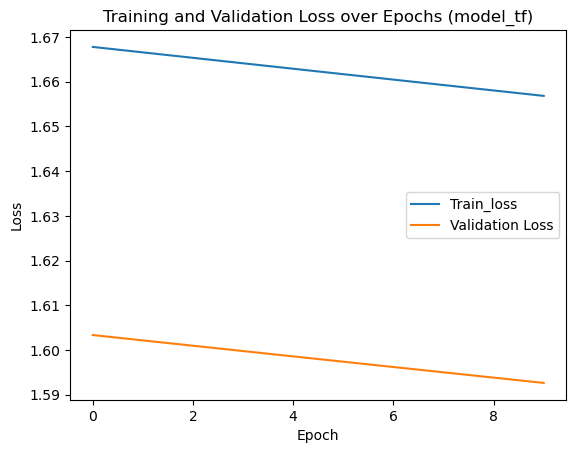

In [26]:
# build model
def build_model(num_features, num_classes, learning_rate):
    tf.keras.backend.clear_session()
    tf.random.set_seed(0)
    model = tf.keras.Sequential()
    model.add(tf.keras.layers.Dense(
        units=num_classes,
        input_shape = (num_features,),
        use_bias=True,
        activation='softmax'
    ))
    optimizer = tf.keras.optimizers.SGD(learning_rate=learning_rate)
    model.compile(optimizer=optimizer, loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

model_tf = build_model(num_features=X_train.shape[1], num_classes=3, learning_rate=0.0001)

# Train the model
history = model_tf.fit(
    X_train, Y_train,
    validation_data = (X_val, Y_val),
    epochs = 10,
    batch_size = 32,
)

# Plot
plt.plot(history.history['loss'], label='Train_loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss over Epochs (model_tf)')
plt.legend()
plt.show()

---
### Step 5: Hyperparameter tuning

### <span style="color:chocolate">Exercise 7:</span> Choosing hyperparameters (10 points)

1. Fine-tune the **learning rate**, **number of epochs**, and **batch size** hyperparameters of *model_tf* to determine the setup that yields the most optimal generalization performance. Feel free to explore various values for these hyperparameters. Hint: you can manually test different hyperparameter values or you can use the [Keras Tuner](https://www.tensorflow.org/tutorials/keras/keras_tuner). 

After identifying your preferred model configuration, print the following information:

2. The first five learned parameters of the model (this should include the bias term);
3. The loss at the final epoch on both the training and validation datasets;
4. The percentage difference between the losses observed on the training and validation datasets.
5. Compare the training/validation loss of the TensorFlow model (model_tf) with the baseline model's loss. Does the TensorFlow model demonstrate an improvement over the baseline model?

Trial 20 Complete [00h 00m 01s]
val_loss: 1.4077750444412231

Best val_loss So Far: 0.8498688340187073
Total elapsed time: 00h 00m 11s
Best learning rate: 0.1
Best batch size: 16
Epoch 1/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.4865 - loss: 1.0075 - val_accuracy: 0.5655 - val_loss: 0.8709
Epoch 2/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 525us/step - accuracy: 0.5339 - loss: 0.8740 - val_accuracy: 0.5571 - val_loss: 0.8497
Epoch 3/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 527us/step - accuracy: 0.5395 - loss: 0.8641 - val_accuracy: 0.5571 - val_loss: 0.8461
Epoch 4/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 524us/step - accuracy: 0.5441 - loss: 0.8613 - val_accuracy: 0.5571 - val_loss: 0.8453
Epoch 5/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 511us/step - accuracy: 0.5450 - loss: 0.8602 - val_accuracy: 0.5571 - val_loss: 0.8453
Epoch 6/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 510us/step - accuracy: 0.5469 - loss: 0.8598 - val_accuracy: 0.5571 - val_loss: 0.8454
Epoch 7/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 511us/step - a

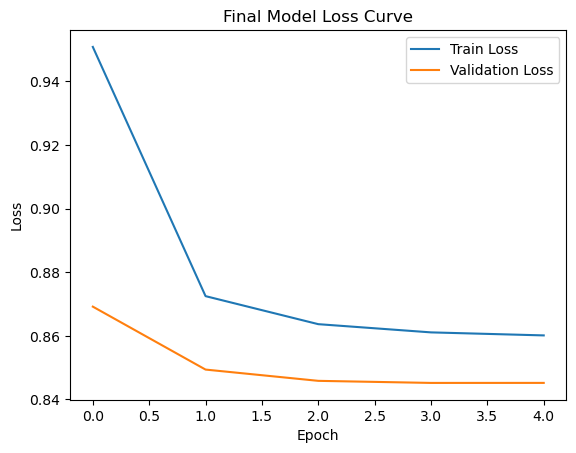

Kernel weights shape: (2, 3)
Bias shape: (3,)
First five learned parameters: [-0.529235   -0.78393656 -1.3146074  -0.43412954 -0.45490864]
Final training loss: 0.8601
Final validation loss: 0.8452
Percentage difference between val and train loss: -1.73%
Baseline train loss: 0.8904 vs. tuned model: 0.8601
Baseline val loss: 0.8334 vs tuned model 0.8452


' The tuned model shows a modest improvement over the baeline on the trainning set (0.89 -> 0.86 loss) but does\nnot generalize that improvement over the baseline on the validation set (0.83 vs 0.84), suggesting the chosen features rating\nand review_date carry limited predictive signal for cocoa percent bucket.'

In [34]:
# Fine-Tune
import keras_tuner as kt

class MultiClassHyperModel(kt.HyperModel):
    def build(self,hp):
        tf.keras.backend.clear_session()
        tf.random.set_seed(0)
        model = tf.keras.Sequential()
        model.add(tf.keras.layers.Dense(
            units=3,
            input_shape=(X_train.shape[1],),
            use_bias=True,
            activation='softmax'
        ))
        hp_learning_rate = hp.Choice('learning_rate', values=[1e-4, 1e-3, 1e-2, 5e-2, 1e-1])
        optimizer = tf.keras.optimizers.SGD(learning_rate=hp_learning_rate)
        model.compile(optimizer=optimizer, loss='sparse_categorical_crossentropy', metrics=['accuracy'])
        return model
    
    def fit(self, hp, model, *args, **kwargs):
        hp_batch_size = hp.Choice('batch_size', values=[16,32,64,128])
        return model.fit(*args, batch_size=hp_batch_size, **kwargs)
    
tuner = kt.Hyperband(
    MultiClassHyperModel(),
    objective='val_loss',
    max_epochs=50,
    factor=3,
    seed=0,
    overwrite=True,
    directory='kt_dir_multiclass',
    project_name='chocolate_tuning'
)

stop_early = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=10)

tuner.search(
    X_train, Y_train,
    validation_data=(X_val, Y_val),
    epochs=50,
    callbacks=[stop_early],
)

best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]
print('Best learning rate:', best_hps.get('learning_rate'))
print('Best batch size:', best_hps.get('batch_size'))

best_model = tuner.hypermodel.build(best_hps)
history = best_model.fit(
    X_train, Y_train,
    validation_data = (X_val, Y_val),
    epochs=50,
    batch_size=best_hps.get('batch_size'),
    callbacks=[stop_early],
)
val_loss_per_epoch = history.history['val_loss']
best_epoch = val_loss_per_epoch.index(min(val_loss_per_epoch)) +1

#Final Model
final_model = tuner.hypermodel.build(best_hps)
final_history = final_model.fit(
    X_train, Y_train,
    validation_data = (X_val, Y_val),
    epochs=best_epoch,
    batch_size=best_hps.get('batch_size'),
)

plt.plot(final_history.history['loss'], label ='Train Loss')
plt.plot(final_history.history['val_loss'], label = 'Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Final Model Loss Curve')
plt.legend()
plt.show()

# 2 First five learned parameters
weights, biases = final_model.get_weights()
print("Kernel weights shape:", weights.shape)
print("Bias shape:", biases.shape)

all_parameters= np.concatenate([weights.flatten(),biases.flatten()])
print('First five learned parameters:', all_parameters[:5])

# 3. Loss at the final epoch
final_train_loss = final_history.history['loss'][-1]
final_val_loss = final_history.history['val_loss'][-1]
print(f"Final training loss: {final_train_loss:.4f}")
print(f"Final validation loss: {final_val_loss:.4f}")

#4. percentage difference
pct_diff = (final_val_loss - final_train_loss) / final_train_loss * 100
print(f"Percentage difference between val and train loss: {pct_diff:.2f}%")

#5. Compare to baseline
p_val = np.tile(baseline_probs, (len(Y_val), 1))
baseline_val_logloss = log_loss_multiclass(Y_val, p_val)
print(f"Baseline train loss: {baseline_train_logloss:.4f} vs. tuned model: {final_train_loss:.4f}")
print(f"Baseline val loss: {baseline_val_logloss:.4f} vs tuned model {final_val_loss:.4f}")

''' The tuned model shows a modest improvement over the baeline on the trainning set (0.89 -> 0.86 loss) but does
not generalize that improvement over the baseline on the validation set (0.83 vs 0.84), suggesting the chosen features rating
and review_date carry limited predictive signal for cocoa percent bucket.'''

---
### Step 6: Evaluation and generalization

### <span style="color:chocolate">Exercise 8:</span> Compute metrics (10 points)

Now that you've determined the optimal set of hyperparameters, it's time to evaluate your optimized model on the test data to gauge its performance in real-world scenarios, commonly known as inference.

1. Calculate aggregate accuracy on both train and test datasets. Note: you will need to convert the vector of predicted probabilities to a class label using the argmax operation. Hint: You can utilize the <span style="color:chocolate">model.predict()</span> method provided by tf.keras. and the <span style="color:chocolate">np.max()</span> method available in NumPy.

2. Does the model demonstrate strong aggregate generalization capabilities? Provide an explanation based on your accuracy observations.

In [36]:
# Get prediction probabilities
train_pred_probs = final_model.predict(X_train)
test_pred_probs = final_model.predict(X_test)

train_pred_labels = np.argmax(train_pred_probs, axis=1)
test_pred_labels = np.argmax(test_pred_probs, axis=1)

# compare against true labels
train_accuracy = np.mean(train_pred_labels == Y_train)
test_accuracy = np.mean(test_pred_labels == Y_test)

print("Train accuracy:", train_accuracy)
print("Test accuracy:", test_accuracy)

'''Does the model demonstrate strong aggregate generalization capabilities?
Yes, in the sense that matters for overfitting: Train accuracy 0.559 and test accuracy 0.565 are nearly equal, 
so whatever the model learned generalizes consistently rather than being an artifact of the training data.
No, in the sense that matters for usefullness: the model barely better than ta baseline that ignores the input features entirely.'''

34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 649us/step
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 621us/step
Train accuracy: 0.5589600742804085
Test accuracy: 0.5654596100278552


'Does the model demonstrate strong aggregate generalization capabilities?\nYes, in the sense that matters for overfitting: Train accuracy 0.559 and test accuracy 0.565 are nearly equal, \nso whatever the model learned generalizes consistently rather than being an artifact of the training data.\nNo, in the sense that matters for usefullness: the model barely better than ta baseline that ignores the input features entirely.'

### <span style="color:chocolate">Exercise 9:</span> Additional metrics (10 points)

Using the test dataset:

1. Plot the confusion matrix. Identify which class the model confuses the most.

2. Determine which class has the lowest precision. What is the precision? Which class is the largest source of false positives?

3. Determine which class has the lowest recall. What is the recall? Which class is the largest source of false negatives?

[[186  17   1]
 [124  16   0]
 [ 12   2   1]]


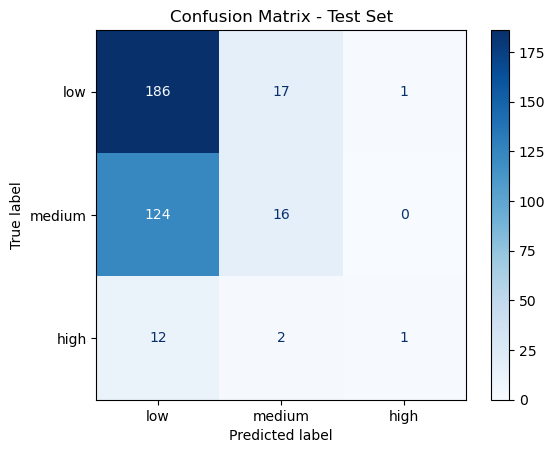

Precision for low: 0.5776
Precision for medium: 0.4571
Precision for high: 0.5000
Lowest precision class: medium
Largest source of false positives for 'medium': 'low' (17 examples)
Recall for low: 0.9118
Recall for medium: 0.1143
Recall for high: 0.0667
Lowest recall class: high
'high' examples are most often misclassified as low' (12 examples)


In [40]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score

# Confusion Matrix
class_names = ['low', 'medium', 'high']
cm = confusion_matrix(Y_test, test_pred_labels, labels =[0,1,2])
print(cm)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(cmap='Blues')
plt.title('Confusion Matrix - Test Set')
plt.show()

# Determine which class has lowest precision
precision = precision_score(Y_test, test_pred_labels, labels=[0,1,2], average=None, zero_division=0)
for name, p in zip(class_names, precision):
    print(f"Precision for {name}: {p:.4f}")

lowest_precision_idx = np.argmin(precision)
print("Lowest precision class:", class_names[lowest_precision_idx])

col = cm[:, lowest_precision_idx].copy()
col[lowest_precision_idx] = 0
fp_source_idx = np.argmax(col)
print(f"Largest source of false positives for '{class_names[lowest_precision_idx]}': "
      f"'{class_names[fp_source_idx]}' ({col[fp_source_idx]} examples)")

# Determine which class has the lowest recall
recall = recall_score(Y_test, test_pred_labels, labels=[0,1,2], average=None, zero_division=0)
for name, r in zip(class_names, recall):
    print(f"Recall for {name}: {r:.4f}")

lowest_recall_idx = np.argmin(recall)
print("Lowest recall class:", class_names[lowest_recall_idx])

row = cm[lowest_recall_idx, :].copy()
row[lowest_recall_idx] = 0
fn_destination_idx = np.argmax(row)
print(f"'{class_names[lowest_recall_idx]}' examples are most often misclassified as "
      f"{class_names[fn_destination_idx]}' ({row[fn_destination_idx]} examples)")

----
#### <span style="color:chocolate">Additional practice question</span> (not graded)

Following the approach in Assignment 4 - Exercise 12, evaluate whether your model shows any signs of unfairness. Explain your findings and propose suggestions for improvement.

In [ ]:
# YOUR CODE HERE